## Points to improve
- dry dates should be taken from the attributes of the shapefile.
- processed images (tile) should be stored in a json file.
- flood map tiles have a gap in between. Polygon dissolve will leave gap.
- store polygon-wise cell-level mean and std values or all values in the dry period? If doing first, how to update with new images? No need to update for IFMIAP and have a static cell-level mean and std values?
- make a class object for mapping floods and push everything in the backend.
- using dry period, process every new image that comes in.

## Interesting points
- The read_reproject function processed 84 scenes in 9 min 28 sec on local computer at overview level 3.

In [1]:
# import required libraries
from ifmiap import utils
from ifmiap import authenticate
from ifmiap import preprocessing
from ifmiap import mapfloods
from ifmiap import postprocessing
import datetime
import pandas as pd
#from shapely.affinity import translate
from matplotlib import pyplot as plt

Echoing from here: /Users/pratyusht/Documents/MapSolveAI/ifmiap/ifmiap/__init__.py


/opt/homebrew/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
%%time
# process certain squares using a list of grid IDs
selected_grid_id = [189, 190, 104, 161, 61, 59]
aoi_union = utils.gpd_to_json(id_list=selected_grid_id, separate=False) # this is for searching scenes
aoi_list = utils.gpd_to_json(id_list=selected_grid_id, separate=True) # this is to seggregate the search


# define the flood date range
pre_flood_dates = utils.date_range('01/05/2020', 60)
post_flood_dates = utils.date_range('20/07/2020', 8)


# the below function can take GDF directly, that it can filter using id and 
# pre and post flood dates can be pulled from the scene itself.
# Doing so will push a lot of the code above to the backend.
# pull sentinel-1 images for pre and post flood duration
pre_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = pre_flood_dates[0], 
                     end_date = pre_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

post_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = post_flood_dates[0], 
                     end_date = post_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

# run this only if the search was performed on the union of AOI
pre_aoi_scene_dict, pre_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, pre_s1_scenes)
post_aoi_scene_dict, post_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, post_s1_scenes)

# convert s1_scenes dictionary to list
pre_s1_scenes = [item for item in list(pre_s1_scenes.values())[0]]
post_s1_scenes = [item for item in list(post_s1_scenes.values())[0]]

for id in pre_aoi_scene_dict:
    print(f'ID: {id}, {len(pre_aoi_scene_dict[id])} pre flood scenes and {len(post_aoi_scene_dict[id])} post flood scenes found.')

ID: 59, 36 pre flood scenes and 7 post flood scenes found.
ID: 61, 35 pre flood scenes and 8 post flood scenes found.
ID: 104, 35 pre flood scenes and 7 post flood scenes found.
ID: 161, 31 pre flood scenes and 6 post flood scenes found.
ID: 189, 25 pre flood scenes and 6 post flood scenes found.
ID: 190, 25 pre flood scenes and 4 post flood scenes found.
CPU times: user 496 ms, sys: 37.9 ms, total: 534 ms
Wall time: 2.45 s


In [3]:
%%time
# read and reproject the images all at once, not separately for each tile
reprojected_pre_combined = {
    stac_id: stac_ds
    for item in pre_s1_scenes
    for (stac_id, stac_ds) in [preprocessing.read_reproject(item)]
}

reprojected_post_combined = {
    stac_id: stac_ds
    for item in post_s1_scenes
    for (stac_id, stac_ds) in [preprocessing.read_reproject(item)]
}

CPU times: user 32.1 s, sys: 4.67 s, total: 36.8 s
Wall time: 9min 28s


In [4]:
%%time
# separate and clip the reprojected image for each tile
reprojected_clipped_pre = {
    id: preprocessing.clip_stac(reprojected_pre_combined, pre_aoi_scene_dict, id)
    for id in selected_grid_id
}

reprojected_clipped_post = {
    id: preprocessing.clip_stac(reprojected_post_combined, post_aoi_scene_dict, id)
    for id in selected_grid_id
}

CPU times: user 9.12 s, sys: 621 ms, total: 9.74 s
Wall time: 9.74 s


In [5]:
%%time
# stack the reprojected and clipped images
stacked_pre = {f'{id}':
                preprocessing.stack_images(reprojected_clipped_pre[id], id)
                for id in reprojected_clipped_pre
               }
stacked_post = {f'{id}':
                preprocessing.stack_images(reprojected_clipped_post[id], id)
                for id in reprojected_clipped_post
               }

# match the cell size and extent of post image stack to the extent of pre stack
for id in stacked_pre:
    stacked_post[id]['vv_stack'] = stacked_post[id]['vv_stack'].rio.reproject_match(stacked_pre[id]['vv_stack']).rio.write_transform(stacked_pre[id]['vv_stack'].rio.transform())
    stacked_post[id]['vh_stack'] = stacked_post[id]['vh_stack'].rio.reproject_match(stacked_pre[id]['vh_stack']).rio.write_transform(stacked_pre[id]['vh_stack'].rio.transform())

CPU times: user 3.51 s, sys: 477 ms, total: 3.98 s
Wall time: 4.16 s


/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.

CPU times: user 2.5 s, sys: 211 ms, total: 2.71 s
Wall time: 2.71 s


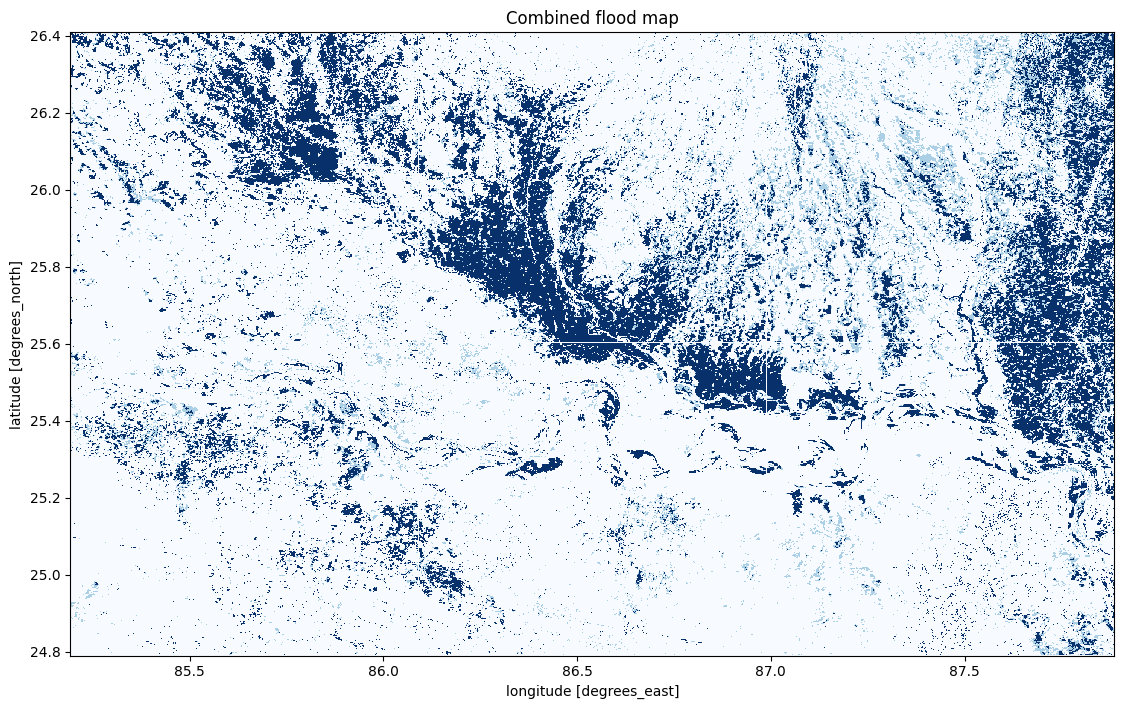

In [12]:
%%time
vv_thd = 2.5
vh_thd = 2.5

# generate the flood rasters
flood_dict = {f'{id}':
              mapfloods.anomaly_cells(stacked_pre[f'{id}'], stacked_post[f'{id}'], vv_thd, vh_thd)
              for id in selected_grid_id
             }


# export the flood rasters
for id in flood_dict:
    outfile_flood = f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent{id}.tif'

    utils.export_xarray(flood_dict[id], outfile_flood)
    

x_min = min(flood_dict[id].x.min() for id in flood_dict)
y_min = min(flood_dict[id].y.min() for id in flood_dict)
x_max = max(flood_dict[id].x.max() for id in flood_dict)
y_max = max(flood_dict[id].y.max() for id in flood_dict)

# export an image of the combined flood rasters
fig, ax = plt.subplots(1, 1, figsize=((x_max - x_min)*5, (y_max - y_min)*5))

for id in flood_dict:
    img = flood_dict[id].plot(ax=ax, cmap='Blues')
    img.colorbar.remove()

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Combined flood map')
    
plt.savefig(outfile_flood.replace('.tif', '.png'), bbox_inches='tight', dpi=100)

In [13]:
%%time

flood_polygon = pd.concat(
    [
        postprocessing.polygonize_flood_raster(flood_dict[id])
        for id in flood_dict
    ], axis=0)

#delta_y = flood_polygon.total_bounds[-1] - flood_polygon.total_bounds[1]
#flood_polygon['geometry'] = flood_polygon['geometry'].apply(lambda geom: translate(geom, xoff=0, yoff=delta_y))

flood_polygon.to_file(f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent.gpkg', index=False)

CPU times: user 4.53 s, sys: 60.8 ms, total: 4.59 s
Wall time: 4.59 s
